In [85]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [86]:
# 1. Load the preprocessed dataset
df = pd.read_csv('../data/interim/olist_ml_processed_dataset.csv')


# 3. Separate the features (X) and the target variable (y)
X = df.drop(columns=['delivery_delay_days']).values.astype('float32')
y = df['delivery_delay_days'].values.astype('float32').reshape(-1, 1)

# 4. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Convert numpy arrays into PyTorch Tensors and create TensorDatasets
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

# 6. Create DataLoaders with a batch size of 512
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Verify the dimensions
print(f"Number of input features: {X.shape[1]}")
print(f"Training samples: {len(X_train)} ({len(train_loader)} batches)")
print(f"Testing samples: {len(X_test)} ({len(test_loader)} batches)")

Number of input features: 7
Training samples: 69223 (136 batches)
Testing samples: 17306 (34 batches)


In [87]:
# Inspect a single batch
features_batch, targets_batch = next(iter(train_loader))
print("Features batch shape:", features_batch.shape)  # Expected: torch.Size([512, 79])
print("Targets batch shape:", targets_batch.shape)    # Expected: torch.Size([512, 1])

Features batch shape: torch.Size([512, 7])
Targets batch shape: torch.Size([512, 1])


In [88]:
class DeliveryDelayNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout_rate=0.2):
        super(DeliveryDelayNN, self).__init__()
        self.hidden_layers = nn.ModuleList([
            nn.Linear(input_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim)
        ])
        # Batch Normalization layers for each hidden layer
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden_dim) for _ in range(6)])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.output_layer = nn.Linear(hidden_dim, 1)
        self._init_weights()

    def _init_weights(self):
        for layer in self.hidden_layers:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, x):
        for layer, bn in zip(self.hidden_layers, self.bns):
            x = layer(x)
            x = bn(x)
            x = self.relu(x)
            x = self.dropout(x)
        return self.output_layer(x)

# 1. Define input dimensions based on the 79 features from our processed dataset
input_dim = 7

# 2. Instantiate the network
model = DeliveryDelayNN(input_dim=input_dim, hidden_dim=256, dropout_rate=0.2)

# 3. Define the Adam optimizer
# A standard starting learning rate is 0.001, which can be tuned later
optimizer = optim.Adam(model.parameters(), lr=0.0008)

# 4. Define Loss Function (Mean Squared Error is standard for regression)
criterion = nn.MSELoss()

# Print out the structured network architecture
print(model)

DeliveryDelayNN(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=7, out_features=256, bias=True)
    (1-5): 5 x Linear(in_features=256, out_features=256, bias=True)
  )
  (bns): ModuleList(
    (0-5): 6 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=256, out_features=1, bias=True)
)


Epoch 01/100 | Train MSE: 88.7690 - Test MSE: 39.4035 | Train MAE: 7.5319 - Test MAE: 4.7352 | Train RMSE: 9.4217 - Test RMSE: 6.2772 | Train R²: -0.8527 - Test R²: 0.1666
Epoch 02/100 | Train MSE: 36.1248 - Test MSE: 33.1533 | Train MAE: 4.6394 - Test MAE: 4.4082 | Train RMSE: 6.0104 - Test RMSE: 5.7579 | Train R²: 0.2460 - Test R²: 0.2988
Epoch 03/100 | Train MSE: 34.9372 - Test MSE: 32.8901 | Train MAE: 4.5802 - Test MAE: 4.4124 | Train RMSE: 5.9108 - Test RMSE: 5.7350 | Train R²: 0.2708 - Test R²: 0.3044
Epoch 04/100 | Train MSE: 34.7258 - Test MSE: 32.6470 | Train MAE: 4.5639 - Test MAE: 4.3957 | Train RMSE: 5.8929 - Test RMSE: 5.7138 | Train R²: 0.2752 - Test R²: 0.3095
Epoch 05/100 | Train MSE: 34.5184 - Test MSE: 32.6191 | Train MAE: 4.5539 - Test MAE: 4.3921 | Train RMSE: 5.8752 - Test RMSE: 5.7113 | Train R²: 0.2796 - Test R²: 0.3101
Epoch 06/100 | Train MSE: 34.3500 - Test MSE: 32.7560 | Train MAE: 4.5317 - Test MAE: 4.4106 | Train RMSE: 5.8609 - Test RMSE: 5.7233 | Train R²

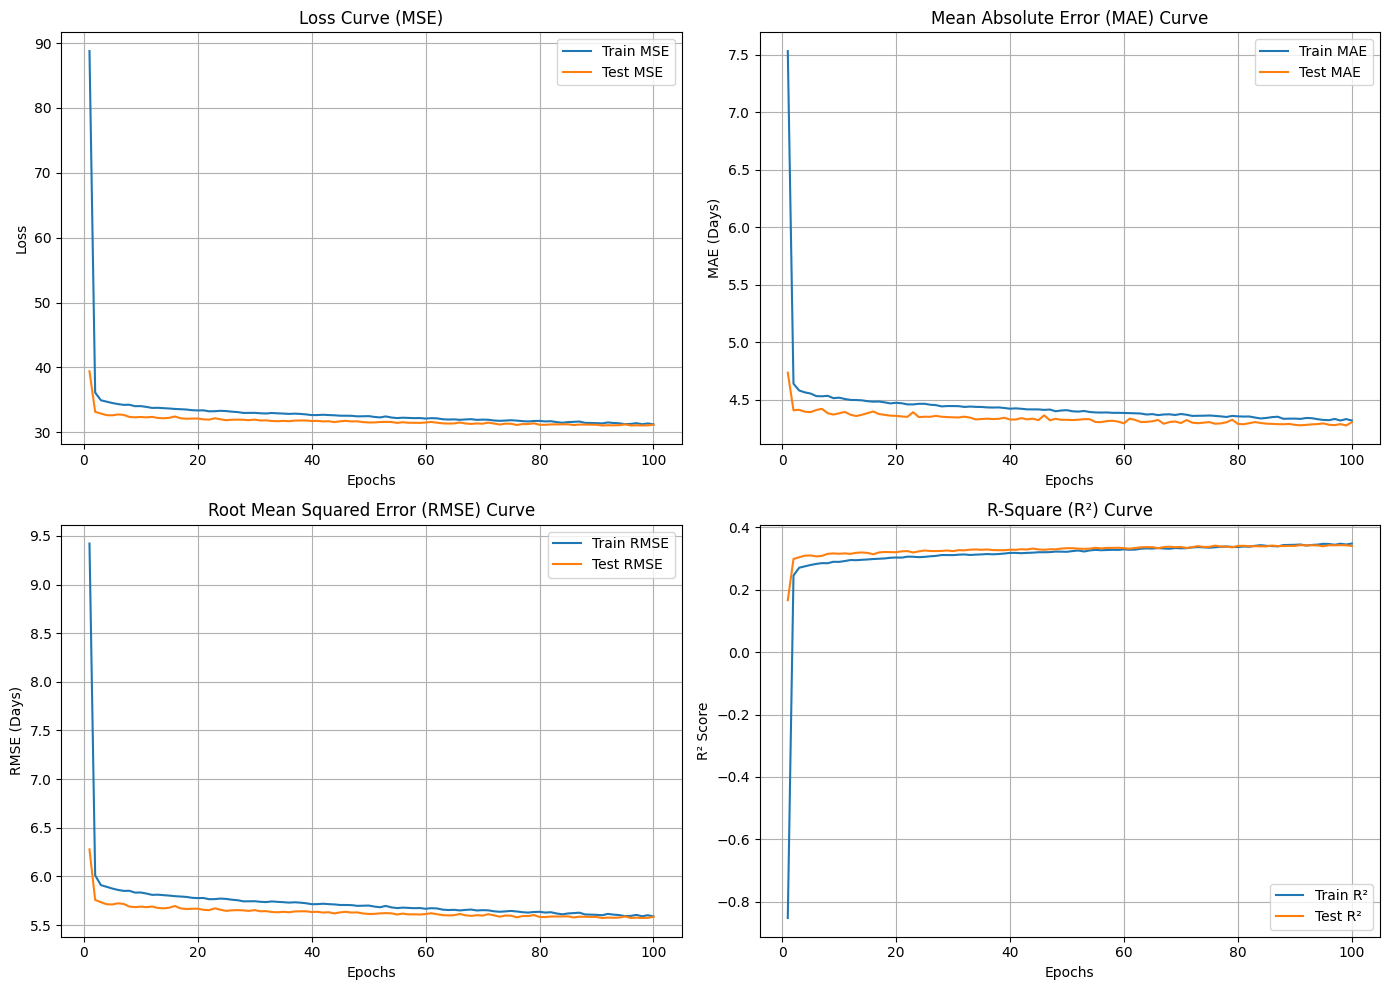

In [89]:
# Training Loop
epochs = 100
history = {
    'train_loss': [], 'test_loss': [],
    'train_mae': [], 'test_mae': [],
    'train_rmse': [], 'test_rmse': [],
    'train_r2': [], 'test_r2': []
}

for epoch in range(epochs):
    model.train()
    all_train_preds = []
    all_train_trues = []
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
        all_train_preds.extend(outputs.detach().cpu().numpy().flatten())
        all_train_trues.extend(batch_y.cpu().numpy().flatten())
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_mae = mean_absolute_error(all_train_trues, all_train_preds)
    train_rmse = np.sqrt(mean_squared_error(all_train_trues, all_train_preds))
    train_r2 = r2_score(all_train_trues, all_train_preds)
    
    model.eval()
    all_test_preds = []
    all_test_trues = []
    running_test_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            running_test_loss += loss.item() * batch_X.size(0)
            all_test_preds.extend(outputs.cpu().numpy().flatten())
            all_test_trues.extend(batch_y.cpu().numpy().flatten())
            
    epoch_test_loss = running_test_loss / len(test_dataset)
    test_mae = mean_absolute_error(all_test_trues, all_test_preds)
    test_rmse = np.sqrt(mean_squared_error(all_test_trues, all_test_preds))
    test_r2 = r2_score(all_test_trues, all_test_preds)
    
    history['train_loss'].append(epoch_train_loss)
    history['test_loss'].append(epoch_test_loss)
    history['train_mae'].append(train_mae)
    history['test_mae'].append(test_mae)
    history['train_rmse'].append(train_rmse)
    history['test_rmse'].append(test_rmse)
    history['train_r2'].append(train_r2)
    history['test_r2'].append(test_r2)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train MSE: {epoch_train_loss:.4f} - Test MSE: {epoch_test_loss:.4f} | "
          f"Train MAE: {train_mae:.4f} - Test MAE: {test_mae:.4f} | "
          f"Train RMSE: {train_rmse:.4f} - Test RMSE: {test_rmse:.4f} | "
          f"Train R²: {train_r2:.4f} - Test R²: {test_r2:.4f}")

# 4. Visualization
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# MSE Loss Curve
axs[0, 0].plot(range(1, epochs + 1), history['train_loss'], label='Train MSE')
axs[0, 0].plot(range(1, epochs + 1), history['test_loss'], label='Test MSE')
axs[0, 0].set_title('Loss Curve (MSE)')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True)

# MAE Curve
axs[0, 1].plot(range(1, epochs + 1), history['train_mae'], label='Train MAE')
axs[0, 1].plot(range(1, epochs + 1), history['test_mae'], label='Test MAE')
axs[0, 1].set_title('Mean Absolute Error (MAE) Curve')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('MAE (Days)')
axs[0, 1].legend()
axs[0, 1].grid(True)

# RMSE Curve
axs[1, 0].plot(range(1, epochs + 1), history['train_rmse'], label='Train RMSE')
axs[1, 0].plot(range(1, epochs + 1), history['test_rmse'], label='Test RMSE')
axs[1, 0].set_title('Root Mean Squared Error (RMSE) Curve')
axs[1, 0].set_xlabel('Epochs')
axs[1, 0].set_ylabel('RMSE (Days)')
axs[1, 0].legend()
axs[1, 0].grid(True)

# R-Square Curve
axs[1, 1].plot(range(1, epochs + 1), history['train_r2'], label='Train R²')
axs[1, 1].plot(range(1, epochs + 1), history['test_r2'], label='Test R²')
axs[1, 1].set_title('R-Square (R²) Curve')
axs[1, 1].set_xlabel('Epochs')
axs[1, 1].set_ylabel('R² Score')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()